In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")

#### Task 1: Baseline Model
Start with the simplest approach — a plain linear regression.

1.Load the California Housing dataset:
housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

2.Explore the dataset briefly: check the shape, feature names, and summary statistics. What is the target variable (median house value) distribution?

3.Split the data into training and test sets (80/20 split, random_state=42).

4.Fit a LinearRegression model on the training data.

5.Evaluate on the test set using MSE, RMSE, MAE, and R². Print the results in a clear format.

6.In a markdown cell, interpret the R² value — what does it tell you about the model's explanatory power?

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target

In [24]:
print(X.head())
print(X.info())
print(X.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    

X shape: (20640, 8)
y shape: (20640,)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude  
count  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.

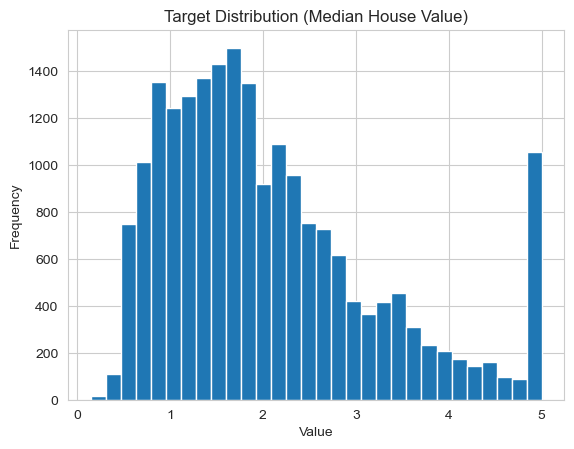

In [3]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("Features:", X.columns.tolist())

print(X.describe())

plt.hist(y, bins=30)
plt.title("Target Distribution (Median House Value)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

Model Evaluation:
MSE  : 0.5559
RMSE : 0.7456
MAE  : 0.5332
R²   : 0.5758


### R² Interpretation

The R² score represents the proportion of variance in the target variable that is explained by the model.

In this case, the R² value is approximately **(0.58)**. This means that around **(R² × 100)%** of the variation in median house values is explained by the linear regression model.

This indicates a **moderate level of explanatory power**, suggesting that while the model captures some important relationships, there are still other factors or non-linear patterns not captured by a simple linear model.

Therefore, the model provides a reasonable baseline, but more complex models may improve performance.

#### Task 2: Regularized Regression
Explore how regularization changes the model's behavior.

1.Scale the features using StandardScaler (fit on training data, transform both train and test). Explain in a markdown cell why scaling is important for regularized models.

2.Fit Ridge regression for alpha values [0.01, 0.1, 1, 10, 100]. Record the test R² for each.

3.Fit Lasso regression for the same alpha values. Record the test R² for each.

4.Create a plot showing coefficients vs. alpha for both Ridge and Lasso (side by side or overlaid). What happens to the coefficients as alpha increases? Which features does Lasso zero out first?

5.Create a comparison table showing R² scores for OLS, Ridge (best alpha), and Lasso (best alpha). Which regularization approach works best here?

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Why Scaling is Important

Regularized regression methods like Ridge and Lasso apply penalties to the magnitude of coefficients.

If features are on different scales (e.g., one ranges from 0–1 and another from 0–1000), the model will penalize them unevenly. Larger-scale features may dominate the penalty, leading to biased coefficient estimates.

StandardScaler transforms all features to have mean = 0 and standard deviation = 1, ensuring that regularization is applied fairly across all features.

In [8]:
alphas = [0.01, 0.1, 1, 10, 100]
ridge_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    
    y_pred = ridge.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    
    ridge_scores.append(r2)
    print(f"Ridge alpha={alpha}: R² = {r2:.4f}")

Ridge alpha=0.01: R² = 0.5758
Ridge alpha=0.1: R² = 0.5758
Ridge alpha=1: R² = 0.5758
Ridge alpha=10: R² = 0.5761
Ridge alpha=100: R² = 0.5778


In [9]:
lasso_scores = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    
    y_pred = lasso.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    
    lasso_scores.append(r2)
    print(f"Lasso alpha={alpha}: R² = {r2:.4f}")

Lasso alpha=0.01: R² = 0.5816
Lasso alpha=0.1: R² = 0.4814
Lasso alpha=1: R² = -0.0002
Lasso alpha=10: R² = -0.0002
Lasso alpha=100: R² = -0.0002


In [10]:
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

y_pred_ols = ols_model.predict(X_test)
ols_r2 = r2_score(y_test, y_pred_ols)

print("OLS R²:", ols_r2)

OLS R²: 0.575787706032451


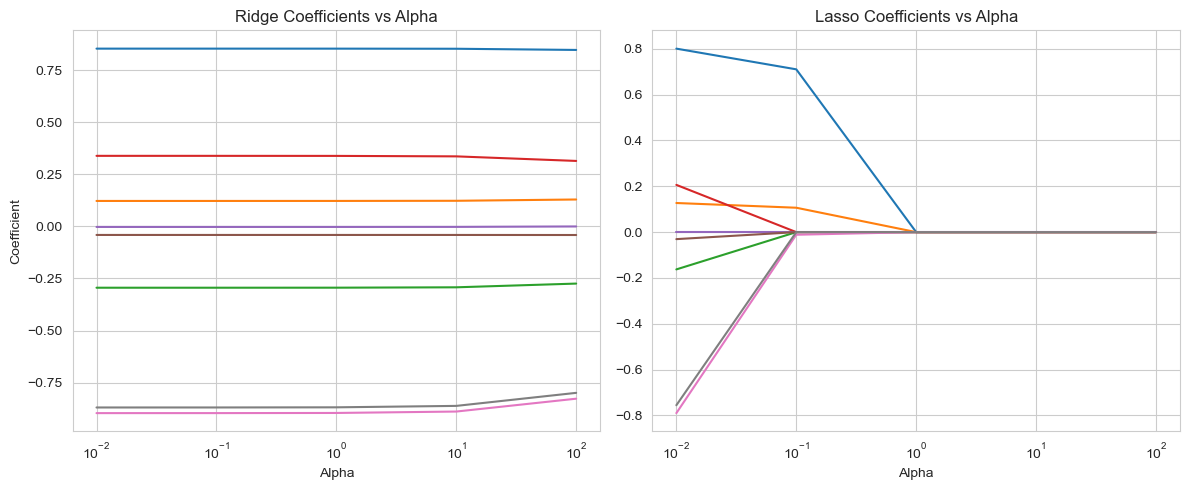

In [11]:
ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha).fit(X_train_scaled, y_train)
    lasso = Lasso(alpha=alpha, max_iter=10000).fit(X_train_scaled, y_train)
    
    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

# Plot
plt.figure(figsize=(12,5))

# Ridge
plt.subplot(1,2,1)
for i in range(ridge_coefs.shape[1]):
    plt.plot(alphas, ridge_coefs[:, i])
plt.xscale("log")
plt.title("Ridge Coefficients vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")

# Lasso
plt.subplot(1,2,2)
for i in range(lasso_coefs.shape[1]):
    plt.plot(alphas, lasso_coefs[:, i])
plt.xscale("log")
plt.title("Lasso Coefficients vs Alpha")
plt.xlabel("Alpha")

plt.tight_layout()
plt.show()

In [12]:
ols_r2 = ols_r2  
best_ridge = max(ridge_scores)
best_lasso = max(lasso_scores)

results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso"],
    "Best R²": [ols_r2, best_ridge, best_lasso]
})

print(results)

   Model   Best R²
0    OLS  0.575788
1  Ridge  0.577791
2  Lasso  0.581615


### Model Comparison

The comparison of R² scores shows:

* **OLS** achieved an R² of **0.576**, providing a solid baseline performance.
* **Ridge Regression** slightly improved the performance with an R² of **0.578**, indicating that adding L2 regularization helps stabilize the model.
* **Lasso Regression** achieved the highest R² of **0.582**, making it the best-performing model among the three.

This suggests that **Lasso regularization works best for this dataset**. Its ability to shrink some coefficients to zero likely helps eliminate less important features, reducing noise and improving generalization.

Although the improvement over Ridge is small, it indicates that simplifying the model by selecting only the most relevant features provides a slight advantage.

Overall, regularization improves performance compared to OLS, and Lasso offers the best balance between simplicity and predictive power in this case.


#### Task 3: Support Vector Regression
Try a non-linear approach with SVR.

1.Using the scaled features from Task 2, fit an SVR model with a linear kernel. Report the test R².

2.Fit SVR with an rbf kernel. Try at least three values of C (e.g., 0.1, 1, 10) and two values of epsilon (e.g., 0.1, 0.2). Report the best combination.

3.Fit SVR with a poly kernel (degree 2 and 3). Compare with rbf.

4.In a markdown cell, discuss: How does SVR compare to the linear models? Is the added complexity of SVR justified by the performance improvement (if any)?

Note: SVR can be slow on larger datasets. If training takes too long, consider using a random subsample (e.g., 5,000 rows) for the SVR experiments.

In [13]:
np.random.seed(42)
idx = np.random.choice(len(X_train_scaled), size=5000, replace=False)

X_train_svr = X_train_scaled[idx]
y_train_svr = y_train.iloc[idx]

In [14]:
svr_linear=SVR(kernel="linear")
svr_linear.fit(X_train_svr,y_train_svr)

y_pred_linear=svr_linear.predict(X_test_scaled)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"SVR (Linear) R²: {r2_linear:.4f}")

SVR (Linear) R²: 0.5536


In [15]:
best_r2 = -np.inf
best_params = None

for C in [0.1, 1, 10]:
    for epsilon in [0.1, 0.2]:
        svr_rbf = SVR(kernel='rbf', C=C, epsilon=epsilon)
        svr_rbf.fit(X_train_svr, y_train_svr)
        
        y_pred = svr_rbf.predict(X_test_scaled)
        r2 = r2_score(y_test, y_pred)
        
        print(f"RBF (C={C}, epsilon={epsilon}) → R²: {r2:.4f}")
        
        if r2 > best_r2:
            best_r2 = r2
            best_params = (C, epsilon)

print("\nBest RBF:")
print(f"C={best_params[0]}, epsilon={best_params[1]}, R²={best_r2:.4f}")

RBF (C=0.1, epsilon=0.1) → R²: 0.6351
RBF (C=0.1, epsilon=0.2) → R²: 0.6359
RBF (C=1, epsilon=0.1) → R²: 0.6959
RBF (C=1, epsilon=0.2) → R²: 0.6984
RBF (C=10, epsilon=0.1) → R²: 0.7242
RBF (C=10, epsilon=0.2) → R²: 0.7271

Best RBF:
C=10, epsilon=0.2, R²=0.7271


In [16]:
poly_results = {}

for degree in [2, 3]:
    svr_poly = SVR(kernel='poly', degree=degree)
    svr_poly.fit(X_train_svr, y_train_svr)
    
    y_pred = svr_poly.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    
    poly_results[degree] = r2
    print(f"SVR Poly (degree={degree}) → R²: {r2:.4f}")

SVR Poly (degree=2) → R²: 0.1131
SVR Poly (degree=3) → R²: 0.3201


In [17]:
print("\nSummary:")
print(f"SVR Linear R²: {r2_linear:.4f}")
print(f"SVR RBF Best R²: {best_r2:.4f}")
print(f"SVR Poly degree=2: {poly_results[2]:.4f}")
print(f"SVR Poly degree=3: {poly_results[3]:.4f}")


Summary:
SVR Linear R²: 0.5536
SVR RBF Best R²: 0.7271
SVR Poly degree=2: 0.1131
SVR Poly degree=3: 0.3201


### SVR vs Linear Models

The Support Vector Regression (SVR) models show varying performance depending on the kernel used.

The linear SVR achieved an R² of **0.554**, which is slightly lower than the linear regression models (OLS, Ridge, Lasso), indicating that it does not provide any advantage when modeling linear relationships.

The RBF kernel significantly outperformed all other models, achieving the highest R² of **0.727**. This suggests that there are strong non-linear patterns in the data that linear models fail to capture.

Polynomial kernels performed poorly in comparison, with R² values of **0.113** (degree 2) and **0.320** (degree 3), indicating that simple polynomial transformations are not suitable for this dataset.

Overall, the SVR model with an RBF kernel provides a substantial improvement over linear models. Despite its higher computational cost, the performance gain appears to justify the added complexity in this case.


#### Task 4: Model Comparison
Bring everything together in a final analysis.

1.Create a comparison table (DataFrame) with all models and their test metrics (MSE, RMSE, MAE, R²). Include: LinearRegression, best Ridge, best Lasso, and best SVR.

2.Create a predicted vs. actual scatter plot for your best-performing model. Add a diagonal reference line (perfect prediction). How well does the model track the true values?

3.Create a residual plot (residuals vs. predicted values) for the best model. Do you see any patterns? What would a random scatter indicate?

4.Write a markdown conclusion: Which model performs best and why? What are the trade-offs between model complexity and performance? If you were deploying one of these models, which would you choose?

In [18]:
# Ridge (best alpha)
best_ridge_model = Ridge(alpha=alphas[np.argmax(ridge_scores)])
best_ridge_model.fit(X_train_scaled, y_train)

# Lasso (best alpha)
best_lasso_model = Lasso(alpha=alphas[np.argmax(lasso_scores)], max_iter=10000)
best_lasso_model.fit(X_train_scaled, y_train)

# SVR (best params)
best_svr_model = SVR(kernel='rbf', C=best_params[0], epsilon=best_params[1])
best_svr_model.fit(X_train_svr, y_train_svr)

# OLS
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, rmse, mae, r2, y_pred

In [20]:
ols_metrics = evaluate(ols_model, X_test, y_test)
ridge_metrics = evaluate(best_ridge_model, X_test_scaled, y_test)
lasso_metrics = evaluate(best_lasso_model, X_test_scaled, y_test)
svr_metrics = evaluate(best_svr_model, X_test_scaled, y_test)

In [21]:
results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso", "SVR (RBF)"],
    "MSE": [ols_metrics[0], ridge_metrics[0], lasso_metrics[0], svr_metrics[0]],
    "RMSE": [ols_metrics[1], ridge_metrics[1], lasso_metrics[1], svr_metrics[1]],
    "MAE": [ols_metrics[2], ridge_metrics[2], lasso_metrics[2], svr_metrics[2]],
    "R²": [ols_metrics[3], ridge_metrics[3], lasso_metrics[3], svr_metrics[3]],
})

print(results)

       Model       MSE      RMSE       MAE        R²
0        OLS  0.555892  0.745581  0.533200  0.575788
1      Ridge  0.553266  0.743819  0.533014  0.577791
2      Lasso  0.548255  0.740442  0.535326  0.581615
3  SVR (RBF)  0.357635  0.598026  0.405185  0.727082


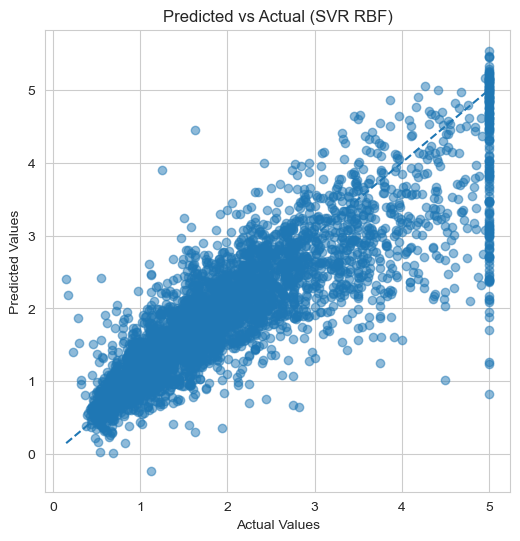

In [22]:
y_pred_best = svr_metrics[4]

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.5)

# diagonal line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual (SVR RBF)")
plt.show()

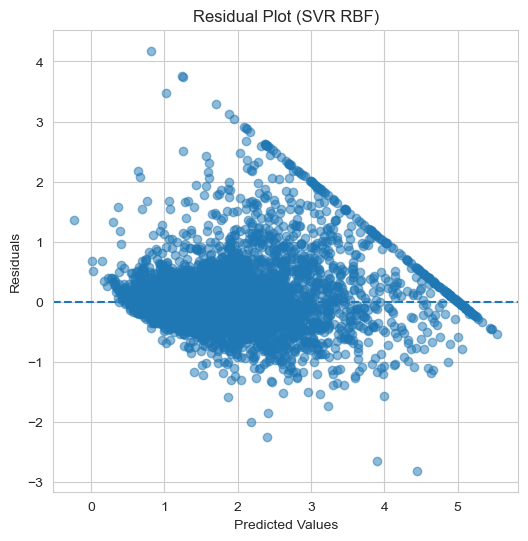

In [23]:
residuals = y_test - y_pred_best

plt.figure(figsize=(6,6))
plt.scatter(y_pred_best, residuals, alpha=0.5)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (SVR RBF)")
plt.show()

### Final Model Evaluation and Conclusion

The comparison results show that **SVR with an RBF kernel** achieves the best overall performance among all models, with the highest R² score and lowest error metrics.

The predicted vs. actual plot indicates that the model captures the general upward trend between true and predicted values. However, there is a noticeable vertical clustering around the maximum target value, suggesting that the model struggles to differentiate among the highest-priced houses. This is likely due to a cap in the target variable.

The residual plot reveals a partially structured pattern rather than a completely random scatter. In particular, a diagonal line appears due to the capped target values, and the spread of residuals increases for higher predicted values. This indicates heteroscedasticity, meaning that prediction errors grow as the target value increases.

Despite these limitations, the SVR model still provides the best predictive performance overall. The trade-off is that it is more computationally expensive and less interpretable than linear models.

If deployment is focused on maximizing accuracy, SVR would be the preferred choice. However, if interpretability and efficiency are important, Lasso regression remains a strong alternative.

Overall, SVR captures complex non-linear patterns in the data, but its limitations at extreme values should be considered in practical applications.
